# COGS 108 - EDA Checkpoint

## Authors

- Daniel Fichthorn: Conceptualization, Methodology, Project administration, Writing - review & editing
- Zilong Feng: Software, Data curation, Analysis, Visualization
- Evan Asti: Background research, Experimental investigation, Writing - original draft, Visualization
- Mulan Zhou: Data curation, Analysis, Methodology, Writing - original draft
- Saidazim Saidov: Software, Analysis, Visualization, Writing - review & editing

# Research Question

This study aims to explore the correlation between real estate and neighborhood characteristics and house prices in the Portland area. Specifically, we examined the impact of factors such as living area, plot size, the number of bedrooms and bathrooms, construction year, and location-related attributes on the sales price. Through exploratory data analysis, we describe the distribution characteristics and interrelationships of each variable, and then evaluate which predictors have the strongest explanatory power for housing price variations.



## Background and Prior Work

The trend of housing prices and public health outcomes are often jointly influenced by macroeconomic and social pressures. Changes in housing affordability, living costs and residents' economic pressure may have a temporal correlation with fluctuations in the risk of drug use and the burden of excessive deaths at the group level. Based on this observation, this study examines whether the time-varying housing market indicators in the Portland area during 2020-2021 have a synchronous change relationship with the monthly number of opioid overdose deaths in Oregon.

Existing public health and social science research usually regards excessive deaths as the result of the combined effect of multiple factors and warns that causal inferences should not be made based on observational correlations. In this stage of the research, our goal is to establish a reliable exploratory foundation for subsequent analysis: unifying the two datasets to a monthly time scale, documenting the principles of data cleaning and aggregation, and using descriptive statistics and visualization methods to depict variable trends, seasonal characteristics, and potential co-variations. In addition, we will initially explore the lag relationship among the variables and discuss the limitations of the research, including the interference of confounding factors, geographical range differences (data from the Portland metropolitan area and the entire state), and the identification challenges that may arise from a shorter observation window.

# Hypothesis


The monthly number of opioid overdose deaths in Oregon (2020-2021) was not related to the year-on-year changes in the housing market indicators in the Portland area (monthly average Zestimate or other price-related measures).
The monthly number of opioid overdose deaths in Oregon (2020-2021) was related to the changes in housing market indicators in the Portland area during the same period. Therefore, periods of higher housing costs and reduced affordability correspond to different average overdose levels.
We also explored whether this association is stronger in a shorter time lag, considering that economic pressure may not immediately affect health outcomes.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
from pathlib import Path

raw_dir = Path("data/00-raw")
housing_path = raw_dir / "portland_housing.csv"
overdose_path = raw_dir / "VSRR_Provisional_Drug_Overdose_Death_Counts_20260218.csv"

housing = pd.read_csv(housing_path)
overdose = pd.read_csv(overdose_path)

housing.shape, overdose.shape

/var/folders/8n/2cr_s3rn6855tg44v5nhvpb00000gn/T/ipykernel_19425/4149474651.py:8: DtypeWarning: Columns (20,50,161,200) have mixed types. Specify dtype option on import or set low_memory=False.
  housing = pd.read_csv(housing_path)


((25731, 348), (81270, 12))

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [15]:
import pandas as pd
from pathlib import Path

raw_dir = Path("data/00-raw")
housing_path = raw_dir / "portland_housing.csv"

housing_raw = pd.read_csv(housing_path, low_memory=False)

cols_lower = {c: c.strip().lower() for c in housing_raw.columns}
housing_raw = housing_raw.rename(columns=cols_lower)

candidate_date_cols = [c for c in housing_raw.columns if "date" in c or "time" in c or "sold" in c or "sale" in c]
date_col = None
for c in ["sold_date", "sale_date", "date_sold", "closing_date", "soldtime", "solddate", "last_sold_date", "lastsolddate", "transaction_date"]:
    if c in housing_raw.columns:
        date_col = c
        break
if date_col is None and len(candidate_date_cols) > 0:
    date_col = candidate_date_cols[0]

candidate_price_cols = []
for c in housing_raw.columns:
    if any(k in c for k in ["zestimate", "price", "value", "amount"]):
        candidate_price_cols.append(c)

price_col = None
for c in ["zestimate", "price", "sold_price", "sale_price", "last_sold_price", "lastsoldprice"]:
    if c in housing_raw.columns:
        price_col = c
        break
if price_col is None and len(candidate_price_cols) > 0:
    price_col = candidate_price_cols[0]

housing = housing_raw.copy()

if date_col is not None:
    housing[date_col] = pd.to_datetime(housing[date_col], errors="coerce")
    housing = housing.dropna(subset=[date_col])
    housing["year_month"] = housing[date_col].dt.to_period("M").astype(str)

if price_col is not None:
    housing[price_col] = pd.to_numeric(housing[price_col], errors="coerce")

keep_cols = []
for c in ["year_month", date_col, price_col, "beds", "bedrooms", "baths", "bathrooms", "sqft", "sqft_living", "living_area", "lot_size", "year_built", "zipcode", "zip", "city", "state", "lat", "latitude", "lon", "longitude"]:
    if c is not None and c in housing.columns and c not in keep_cols:
        keep_cols.append(c)

housing_small = housing[keep_cols].copy() if len(keep_cols) > 0 else housing.copy()

summary = {
    "date_col": date_col,
    "price_col": price_col,
    "raw_shape": housing_raw.shape,
    "clean_shape": housing_small.shape,
    "date_missing_after_parse": int(housing_raw[date_col].isna().sum()) if date_col is not None else None,
    "price_missing_after_parse": int(housing_small[price_col].isna().sum()) if price_col is not None and price_col in housing_small.columns else None,
}

housing_small.head(), summary

(  year_month                datesold  zestimate  bedrooms  bathrooms  \
 0    1970-01 1970-01-01 00:27:01.560   317406.0       3.0        3.0   
 1    1970-01 1970-01-01 00:26:59.140        NaN       3.0        3.0   
 2    1970-01 1970-01-01 00:27:02.760   512355.0       4.0        3.0   
 3    1970-01 1970-01-01 00:27:02.760        NaN       3.0        1.0   
 4    1970-01 1970-01-01 00:27:02.510        NaN       6.0        3.0   
 
     latitude   longitude  
 0  45.543571 -122.441765  
 1  45.547585 -122.453224  
 2  45.488228 -122.444420  
 3  45.526634 -122.464088  
 4  45.511238 -122.431534  ,
 {'date_col': 'datesold',
  'price_col': 'zestimate',
  'raw_shape': (25731, 348),
  'clean_shape': (25731, 7),
  'date_missing_after_parse': 0,
  'price_missing_after_parse': 1974})

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [16]:
import pandas as pd
from pathlib import Path

p = Path("data/00-raw") / "VSRR_Provisional_Drug_Overdose_Death_Counts_20260218.csv"
df = pd.read_csv(p, low_memory=False)
df.columns = [c.strip().lower() for c in df.columns]

df["state"] = df["state"].astype(str).str.strip().str.lower()
df = df[df["state"].eq("or")].copy()

df["indicator"] = df["indicator"].astype(str).str.strip()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

date1 = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str), format="%Y-%B", errors="coerce")
date2 = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str), format="%Y-%b", errors="coerce")
df["date"] = date1.fillna(date2)
df = df.dropna(subset=["date"])
df["year_month"] = df["date"].dt.to_period("M").astype(str)

df["data value"] = pd.to_numeric(df["data value"], errors="coerce")

df = df[(df["date"] >= "2020-01-01") & (df["date"] <= "2021-12-31")].copy()

opioid_key = "Opioids (T40.0-T40.4,T40.6)"
overdose_key = "Number of Drug Overdose Deaths"

df_opioid = df[df["indicator"].eq(opioid_key)].copy()
df_overdose = df[df["indicator"].eq(overdose_key)].copy()

opioid_monthly = (
    df_opioid.groupby("year_month", as_index=False)["data value"]
    .sum(min_count=1)
    .rename(columns={"data value": "opioid_deaths"})
)

overdose_monthly = (
    df_overdose.groupby("year_month", as_index=False)["data value"]
    .sum(min_count=1)
    .rename(columns={"data value": "overdose_deaths"})
)

summary2 = {
    "state_filtered_shape": df.shape,
    "opioid_rows": df_opioid.shape,
    "overdose_rows": df_overdose.shape,
    "opioid_monthly_shape": opioid_monthly.shape,
    "overdose_monthly_shape": overdose_monthly.shape,
    "opioid_year_month_min": opioid_monthly["year_month"].min() if len(opioid_monthly) else None,
    "opioid_year_month_max": opioid_monthly["year_month"].max() if len(opioid_monthly) else None,
    "overdose_year_month_min": overdose_monthly["year_month"].min() if len(overdose_monthly) else None,
    "overdose_year_month_max": overdose_monthly["year_month"].max() if len(overdose_monthly) else None,
}

opioid_monthly.head(), overdose_monthly.head(), summary2

(  year_month  opioid_deaths
 0    2020-01          339.0
 1    2020-02          341.0
 2    2020-03          346.0
 3    2020-04          351.0
 4    2020-05          397.0,
   year_month  overdose_deaths
 0    2020-01            621.0
 1    2020-02            624.0
 2    2020-03            633.0
 3    2020-04            644.0
 4    2020-05            701.0,
 {'state_filtered_shape': (288, 14),
  'opioid_rows': (24, 14),
  'overdose_rows': (24, 14),
  'opioid_monthly_shape': (24, 2),
  'overdose_monthly_shape': (24, 2),
  'opioid_year_month_min': '2020-01',
  'opioid_year_month_max': '2021-12',
  'overdose_year_month_min': '2020-01',
  'overdose_year_month_max': '2021-12'})

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [19]:
import pandas as pd
from pathlib import Path
import numpy as np

processed_dir = Path("data/02-processed")
processed_dir.mkdir(parents=True, exist_ok=True)

h = housing_raw.copy()
h.columns = [c.strip().lower() for c in h.columns]

date_col = "datesold" if "datesold" in h.columns else None
price_col = "zestimate" if "zestimate" in h.columns else None

x = pd.to_numeric(h[date_col], errors="coerce")
use_ms = bool((x.dropna() > 1e11).mean() > 0.9)
h["date"] = pd.to_datetime(x, unit="ms", errors="coerce") if use_ms else pd.to_datetime(h[date_col], errors="coerce")
h = h.dropna(subset=["date"])

h = h[(h["date"] >= "2020-01-01") & (h["date"] <= "2021-12-31")].copy()
h["year_month"] = h["date"].dt.to_period("M").astype(str)

h[price_col] = pd.to_numeric(h[price_col], errors="coerce")

housing_monthly = (
    h.groupby("year_month", as_index=False)[price_col]
    .mean()
    .rename(columns={price_col: "housing_zestimate_mean"})
)

merged = (
    housing_monthly.merge(opioid_monthly, on="year_month", how="inner")
    .merge(overdose_monthly, on="year_month", how="inner")
)

merged["year_month"] = pd.to_datetime(merged["year_month"] + "-01")
merged = merged.sort_values("year_month").reset_index(drop=True)

out_path = processed_dir / "monthly_housing_overdose_2020_2021.csv"
merged.to_csv(out_path, index=False)

diagnostic = {
    "date_col": date_col,
    "date_parsing_unit_ms": use_ms,
    "housing_rows_2020_2021": h.shape,
    "housing_monthly_shape": housing_monthly.shape,
    "merged_shape": merged.shape,
    "merged_min": merged["year_month"].min() if len(merged) else None,
    "merged_max": merged["year_month"].max() if len(merged) else None,
    "out_path": str(out_path),
}

merged.head(), diagnostic

(  year_month  housing_zestimate_mean  opioid_deaths  overdose_deaths
 0 2020-06-01           465753.666667          407.0            701.0
 1 2020-07-01           653614.510478          420.0            715.0
 2 2020-08-01           657457.913413          437.0            734.0
 3 2020-09-01           653510.883099          443.0            745.0
 4 2020-10-01           629304.356298          467.0            763.0,
 {'date_col': 'datesold',
  'date_parsing_unit_ms': True,
  'housing_rows_2020_2021': (25731, 350),
  'housing_monthly_shape': (14, 2),
  'merged_shape': (14, 4),
  'merged_min': Timestamp('2020-06-01 00:00:00'),
  'merged_max': Timestamp('2021-07-01 00:00:00'),
  'out_path': 'data/02-processed/monthly_housing_overdose_2020_2021.csv'})

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

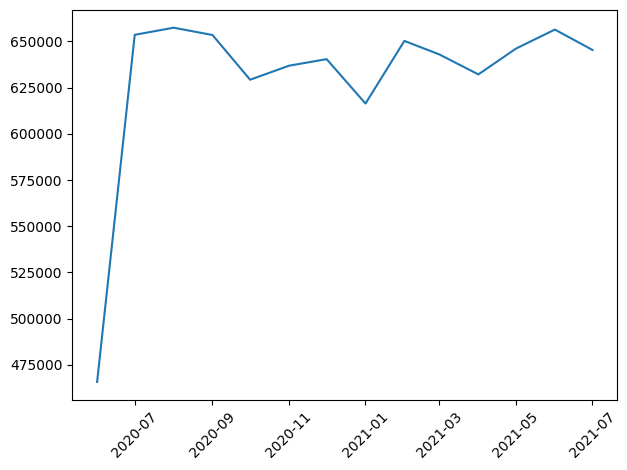

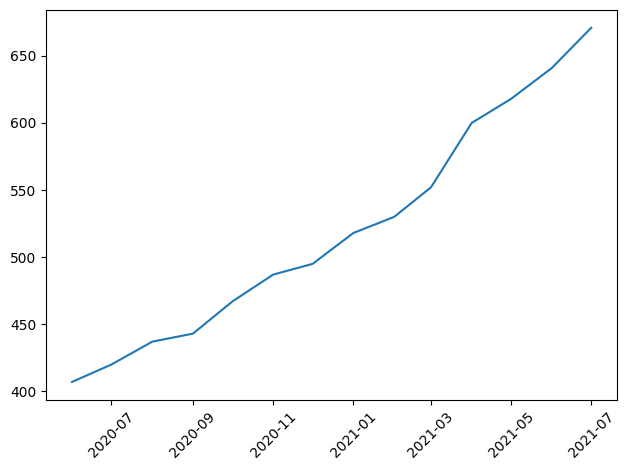

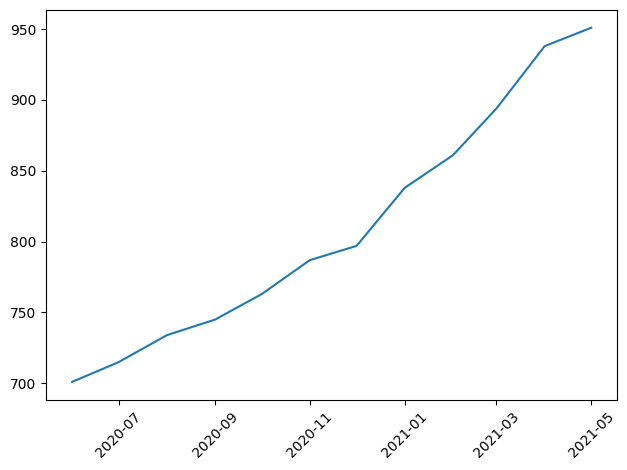

,housing_zestimate_mean,opioid_deaths,overdose_deaths
housing_zestimate_mean,1.000000,0.361752,0.327932
opioid_deaths,0.361752,1.000000,0.995261
overdose_deaths,0.327932,0.995261,1.000000


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path("data/02-processed") / "monthly_housing_overdose_2020_2021.csv")
df["year_month"] = pd.to_datetime(df["year_month"])

plt.figure()
plt.plot(df["year_month"], df["housing_zestimate_mean"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["year_month"], df["opioid_deaths"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["year_month"], df["overdose_deaths"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df[["housing_zestimate_mean", "opioid_deaths", "overdose_deaths"]].corr()

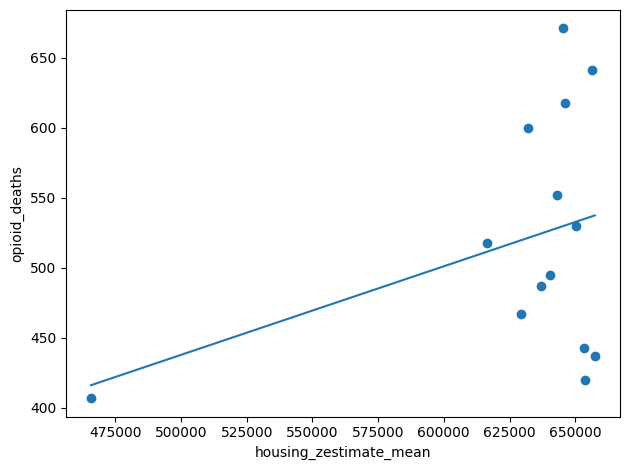

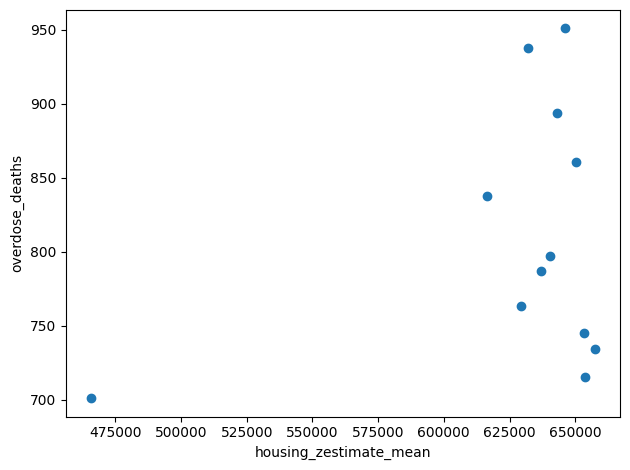

,lag_months,corr_housing_opioid,corr_housing_overdose
0,0,0.361752,0.327932
1,1,0.375809,0.328053
2,2,0.343695,0.352893
3,3,0.354558,0.361236


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path("data/02-processed") / "monthly_housing_overdose_2020_2021.csv")
df["year_month"] = pd.to_datetime(df["year_month"])
df = df.sort_values("year_month").reset_index(drop=True)

x = df["housing_zestimate_mean"].astype(float).to_numpy()
y1 = df["opioid_deaths"].astype(float).to_numpy()
y2 = df["overdose_deaths"].astype(float).to_numpy()

m1, b1 = np.polyfit(x, y1, 1)
m2, b2 = np.polyfit(x, y2, 1)

x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)

plt.figure()
plt.scatter(x, y1)
plt.plot(x_line, m1 * x_line + b1)
plt.xlabel("housing_zestimate_mean")
plt.ylabel("opioid_deaths")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(x, y2)
plt.plot(x_line, m2 * x_line + b2)
plt.xlabel("housing_zestimate_mean")
plt.ylabel("overdose_deaths")
plt.tight_layout()
plt.show()

def lag_corr(a, b, lag):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if lag == 0:
        aa, bb = a, b
    else:
        aa, bb = a[:-lag], b[lag:]
    mask = np.isfinite(aa) & np.isfinite(bb)
    if mask.sum() < 3:
        return np.nan
    return float(np.corrcoef(aa[mask], bb[mask])[0, 1])

lags = [0, 1, 2, 3]
lag_table = pd.DataFrame({
    "lag_months": lags,
    "corr_housing_opioid": [lag_corr(x, y1, l) for l in lags],
    "corr_housing_overdose": [lag_corr(x, y2, l) for l in lags],
})

lag_table

## Ethics

The data used in this study are all publicly available aggregated data: housing valuation indicators in the Portland area, and the monthly provisional number of opioid overdose deaths in Oregon. This study is merely an exploratory analysis and does not involve causal inference. The potential risk lies in the misinterpretation or stigmatization of the outcome: excessive deaths are influenced by multiple structural factors (including medical accessibility, policy changes, economic environment, statistical standards, etc.), and their correlation with housing indicators is likely to reflect confounding effects rather than direct causal relationships.

To reduce the above-mentioned risks, we have taken several measures in the research design and presentation: First, clearly state the research limitations and avoid using causal inference language; Secondly, use monthly aggregated data instead of individual records to reduce privacy risks; Thirdly, it is emphasized that research conclusions should not be applied to the judgment of individuals or specific communities. At the same time, we have also noticed the measurement error of the data itself: the death figures are provisional values and may be revised later. Housing valuations (such as Zestimate) may have systematic biases. The findings of this study will be presented in a prudent manner, aiming to identify patterns of change at the macro level rather than make attributions.

## Team Expectations 

We collaborate through a shared GitHub repository and synchronize progress in group chats. Project tasks are tracked through Issues, with clear responsible persons and key decisions recorded. Each member submits their work content through commit. Before merging, a review is conducted to ensure the reproducibility of the notebook.

The role division is as follows:
- Daniel Fichthorn: Project coordination, final integration and quality inspection
- Zilong Feng: Data Pipeline and Analysis Code Implementation
- Evan Asti: Background research, visualization support and document drafting
- Mulan Zhou: Data cleaning, exploratory analysis and manuscript drafting
- Saidazim Saidov: Visualization, result interpretation and manuscript polishing

The team synchronizes at least once a week to ensure that the notebook can run completely from start to finish. When encountering blockages, raise them as early as possible and adjust the tasks promptly to ensure progress.

## Project Timeline Proposal

Week 1: Finalize the research questions, complete the organization and recording of data sources, clean and align the data set to a unified monthly timeline, and conduct core exploratory data analysis (including trend charts, correlation analysis, and scatter plots with simple fitting).

Week 2: Refine the variable definitions and conduct robustness tests. The system examines the lag relationship among variables and compares different indicators (such as opioid-specific deaths and all-cause overdose deaths). Record the situation of missing records, the impact of screening conditions, and other possible aggregation methods.

Week 3: Build basic statistical models (such as linear regression, with corresponding explanatory limitations) to quantify the associations between variables and present uncertainties. When conditions permit, introduce additional background variables to clearly distinguish descriptive results from speculative interpretations.

Week 4: Polish the narrative logic, refine the ethical and limitation explanations, ensure reproducibility, and complete the final report and the charts that can be used for presentation. Conduct a comprehensive operation test to confirm that the warehouse structure and notebook execution are correct.